## Introduction

In this notebook, we will build a Spatio-Temporal Distribution Model (SDM) using Long Short-Term Memory (LSTM) networks.

## Import libraries and data loader

In [32]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np 
import pandas as pd

Reading the fish presence file csv that I downloaded from GBIF

In [33]:
# Import dataset
fish_path = "../../dataset/fish_env_2022_2025.csv"
fish_ds = pd.read_csv(fish_path)
print(fish_ds.shape)

(209, 33)


Then, I read env from .nc file I got from Copernius

In [34]:
# Read env .nc data
import xarray as xr
thetao_env_2025 = xr.open_dataset('../../dataset/env_copernius/env_2025/phy_thetao_2025.nc' , engine='netcdf4')
uo_vo_env_2025 = xr.open_dataset('../../dataset/env_copernius/env_2025/phy_uo_vo_2025.nc' , engine='netcdf4')
so_env_2025 = xr.open_dataset('../../dataset/env_copernius/env_2025/phy_so_2025.nc' , engine='netcdf4')
mlotst_env_2025 = xr.open_dataset('../../dataset/env_copernius/env_2025/phy_mlotst_2025.nc' , engine='netcdf4')
chla_env_2025 = xr.open_dataset('../../dataset/env_copernius/env_2025/bio_chl_phyc_2025.nc' , engine='netcdf4')
o2_env_2025 = xr.open_dataset('../../dataset/env_copernius/env_2025/bio_o2_2025.nc' , engine='netcdf4')

## Generate pseuedo-absences
In SDMs, there are just only presence-only point of fish. To solve problem imbalance class in this case, we need to generate pseudo-absences by:
1. Create a mask of land/sea in region area
2. Randomly sample points from the mask of sea and not a location of presence fish and generate pseudo-absences with ratio 1:1 absences-presences.
3. Output: pixel of absences


## Generate Pseudo-Absences (Land/Sea Mask + 1:1 Sampling)

Steps:
1. Build a land/sea mask from the NetCDF environmental file.
2. Sample sea pixels that do **not** overlap presence points.
3. Create pseudo-absences with ratio 1:1 (absence:presence).
4. Output pixels/points for LSTM training.

In [35]:
import xarray as xr
import numpy as np
import pandas as pd

# --- 1) Load presence-only fish points ---
fish_path = "../../dataset/fish_env_2022_2025.csv"
fish_df = pd.read_csv(fish_path)

# Expecting columns: decimalLatitude, decimalLongitude
fish_df = fish_df.dropna(subset=["decimalLatitude", "decimalLongitude"]).rename(
    columns={"decimalLatitude": "lat", "decimalLongitude": "lon"}
)

print(f"Presence points: {len(fish_df)}")
fish_df.head()

Presence points: 209


,Unnamed: 0.1,Unnamed: 0,scientificName,taxonKey,individualCount,organismQuantity,organismQuantityType,sex,lifeStage,occurrenceStatus,...,datetime,date,thetao,so,mlotst,uo,vo,chl,phyc,o2
0,0,25,"Katsuwonus pelamis (Linnaeus, 1758)",2374191,NaN,NaN,NaN,NaN,NaN,PRESENT,...,2022-04-21 00:00:00+00:00,2022-04-21,29.653404,33.261730,10.463024,0.106001,-0.033837,0.415881,2.467258,222.68826
1,1,26,"Katsuwonus pelamis (Linnaeus, 1758)",2374191,NaN,NaN,NaN,NaN,NaN,PRESENT,...,2022-05-20 09:27:00+00:00,2022-05-20,28.309855,33.551280,15.125868,0.605374,1.006352,0.303127,1.938882,204.01666
2,2,27,"Katsuwonus pelamis (Linnaeus, 1758)",2374191,NaN,NaN,NaN,NaN,NaN,PRESENT,...,2022-08-21 00:00:00+00:00,2022-08-21,29.795350,33.158340,17.431349,0.036713,0.106544,NaN,NaN,NaN
3,3,28,"Katsuwonus pelamis (Linnaeus, 1758)",2374191,NaN,NaN,NaN,NaN,NaN,PRESENT,...,2022-08-09 00:00:00+00:00,2022-08-09,30.961650,34.126827,11.005076,0.379502,-0.424626,0.156874,1.927708,198.83006
4,4,215,"Pampus argenteus (Euphrasen, 1788)",2397682,NaN,NaN,NaN,Indeterminate,Adult,PRESENT,...,2022-07-17 12:40:00+00:00,2022-07-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# --- 2) Build land/sea mask from NetCDF env file ---
# Update the file below to your environmental NetCDF
env_nc_path = "../../dataset/env_copernius/env_2025/phy_thetao_2025.nc"

# Open dataset (let xarray auto-pick engine)
ds_env = xr.open_dataset(env_nc_path)

# Use the first data variable as a mask source
mask_var_name = list(ds_env.data_vars)[0]
mask_var = ds_env[mask_var_name]

# If time dimension exists, use the first timestep
if "time" in mask_var.dims:
    mask_var = mask_var.isel(time=0)

# Get coordinate arrays
lats = mask_var["lat"].values if "lat" in mask_var.coords else mask_var["latitude"].values
lons = mask_var["lon"].values if "lon" in mask_var.coords else mask_var["longitude"].values

# Sea mask: non-NaN => sea
sea_mask = ~np.isnan(mask_var.values)

print(f"Mask var: {mask_var_name}")
print(f"Mask shape: {sea_mask.shape}")
print(f"Lat range: {lats.min():.2f} to {lats.max():.2f}")
print(f"Lon range: {lons.min():.2f} to {lons.max():.2f}")

Mask var: thetao
Mask shape: (1, 582, 1372)
Lat range: -10.75 to 37.67
Lon range: 27.25 to 141.50


In [37]:
# --- 3) Sample pseudo-absences from sea mask (1:1 with presences) ---

def build_presence_grid_mask(presence_df, lats, lons):
    # Find nearest grid cell for each presence point
    lat_idx = np.searchsorted(lats, presence_df["lat"].values)
    lon_idx = np.searchsorted(lons, presence_df["lon"].values)

    lat_idx = np.clip(lat_idx, 0, len(lats) - 1)
    lon_idx = np.clip(lon_idx, 0, len(lons) - 1)

    presence_mask = np.zeros((len(lats), len(lons)), dtype=bool)
    presence_mask[lat_idx, lon_idx] = True
    return presence_mask

presence_mask = build_presence_grid_mask(fish_df, lats, lons)

# Eligible sea cells: sea and not presence
eligible_mask = sea_mask & ~presence_mask
eligible_indices = np.argwhere(eligible_mask)

n_presences = len(fish_df)
n_absences = n_presences  # 1:1 ratio

if len(eligible_indices) < n_absences:
    raise ValueError(
        f"Not enough eligible sea pixels: {len(eligible_indices)} available, {n_absences} needed."
    )

selected_idx = eligible_indices[
    np.random.choice(len(eligible_indices), size=n_absences, replace=False)
]

abs_lats = lats[selected_idx[:, 0]]
abs_lons = lons[selected_idx[:, 1]]

absence_df = pd.DataFrame({"lat": abs_lats, "lon": abs_lons, "presence": 0})

presence_out = fish_df[["lat", "lon"]].copy()
presence_out["presence"] = 1

sdm_points = pd.concat([presence_out, absence_df], ignore_index=True)

print(f"Absence points generated: {len(absence_df)}")
print(f"Total SDM points: {len(sdm_points)}")
absence_df.head()

Absence points generated: 209
Total SDM points: 418


,lat,lon,presence
0,-10.75,51.666672,0
1,-10.75,37.500000,0
2,-10.75,49.916672,0
3,-10.75,39.750000,0
4,-10.75,31.750000,0


Absence mask pixels: 209


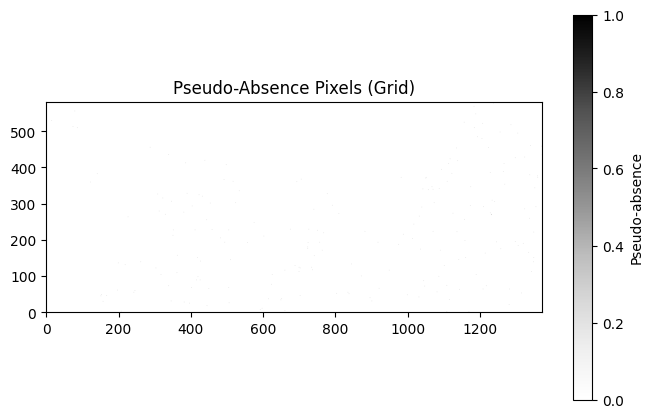

In [38]:
# --- 4) Output pseudo-absence pixels (grid mask) ---
absence_mask = np.zeros_like(sea_mask, dtype=bool)
absence_mask[selected_idx[:, 0], selected_idx[:, 1], selected_idx[:, 2]] = True

print(f"Absence mask pixels: {absence_mask.sum()}")

# Optional: visualize absence mask (squeeze to 2D if needed)
import matplotlib.pyplot as plt

# Remove singleton dimensions for visualization
absence_mask_2d = np.squeeze(absence_mask)

plt.figure(figsize=(8, 5))
plt.imshow(absence_mask_2d, cmap="Greys", origin="lower")
plt.title("Pseudo-Absence Pixels (Grid)")
plt.colorbar(label="Pseudo-absence")
plt.show()

## Step 1: Read Multiple Environmental NetCDF Files

Load all environmental variables from multiple .nc files.

In [39]:
import xarray as xr
import glob
from pathlib import Path

# Load multiple environmental NetCDF files
env_dir = "../../dataset/env_copernius/env_2025/"
env_files = {
    "thetao": "phy_thetao_2025.nc",
    "so": "phy_so_2025.nc",
    "uo_vo": "phy_uo_vo_2025.nc",
    "mlotst": "phy_mlotst_2025.nc",
    "chl": "bio_chl_phyc_2025.nc",
    "o2": "bio_o2_2025.nc"
}

env_datasets = {}
for var_name, filename in env_files.items():
    filepath = Path(env_dir) / filename
    if filepath.exists():
        try:
            ds = xr.open_dataset(filepath)
            env_datasets[var_name] = ds
            print(f"✓ Loaded {var_name}: {filepath.name}")
        except Exception as e:
            print(f"✗ Failed to load {var_name}: {e}")
    else:
        print(f"✗ File not found: {filepath}")

print(f"\nTotal environmental datasets loaded: {len(env_datasets)}")

✓ Loaded thetao: phy_thetao_2025.nc
✓ Loaded so: phy_so_2025.nc
✓ Loaded uo_vo: phy_uo_vo_2025.nc
✓ Loaded mlotst: phy_mlotst_2025.nc
✓ Loaded chl: bio_chl_phyc_2025.nc
✓ Loaded o2: bio_o2_2025.nc

Total environmental datasets loaded: 6


## Step 2: Extract Environmental Features for Each Point

Extract temporal environmental data for each presence/absence point.

In [40]:
def extract_temporal_features(point_df, env_datasets, time_window=12):
    """
    Extract temporal environmental features for each point.
    
    Args:
        point_df: DataFrame with 'lat', 'lon', 'presence' columns
        env_datasets: Dict of xarray datasets
        time_window: Number of time steps to extract
    
    Returns:
        X: Temporal features (N, T, F) where F = number of env variables
        y: Labels (N,)
    """
    features_list = []
    labels = point_df['presence'].values
    
    for idx, row in point_df.iterrows():
        lat, lon = row['lat'], row['lon']
        point_features = []
        
        for var_name, ds in env_datasets.items():
            # Get the variable (first data variable in dataset)
            var = ds[list(ds.data_vars)[0]]
            
            # Select nearest point
            try:
                point_data = var.sel(lat=lat, lon=lon, method='nearest')
                
                # Get temporal data (last time_window steps)
                if 'time' in point_data.dims:
                    temporal_data = point_data.isel(time=slice(-time_window, None))
                    point_features.append(temporal_data.values)
                else:
                    # If no time dimension, repeat the value
                    point_features.append(np.repeat(point_data.values, time_window))
            except Exception as e:
                # Fill with NaN if extraction fails
                point_features.append(np.full(time_window, np.nan))
        
        # Stack features: (time_window, n_features)
        features_list.append(np.column_stack(point_features))
    
    X = np.array(features_list)  # (N, T, F)
    y = labels
    
    return X, y

# Extract features for all SDM points
print("Extracting temporal features for SDM points...")
X_raw, y_raw = extract_temporal_features(sdm_points, env_datasets, time_window=12)

print(f"X shape: {X_raw.shape}")  # (N, T, F)
print(f"y shape: {y_raw.shape}")  # (N,)
print(f"Number of features: {X_raw.shape[2]}")

Extracting temporal features for SDM points...
X shape: (418, 12, 6)
y shape: (418,)
Number of features: 6


## Step 3: Data Preprocessing

Normalize features and handle missing values for LSTM training.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Handle missing values (fill with 0 for land mask)
X_filled = np.nan_to_num(X_raw, nan=0.0)

# Reshape for normalization: (N*T, F)
N, T, n_features = X_filled.shape  # Changed F to n_features to avoid shadowing torch.nn.functional
X_reshaped = X_filled.reshape(-1, n_features)

# Z-score normalization for dynamic variables (LSTM)
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_reshaped)

# Reshape back to (N, T, n_features)
X_normalized = X_normalized.reshape(N, T, n_features)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

print(f"Training set: X={X_train_tensor.shape}, y={y_train_tensor.shape}")
print(f"Test set: X={X_test_tensor.shape}, y={y_test_tensor.shape}")
print(f"Class distribution - Train: {np.bincount(y_train.astype(int))}")
print(f"Class distribution - Test: {np.bincount(y_test.astype(int))}")

Training set: X=torch.Size([334, 12, 6]), y=torch.Size([334])
Test set: X=torch.Size([84, 12, 6]), y=torch.Size([84])
Class distribution - Train: [167 167]
Class distribution - Test: [42 42]


## Step 4: Create DataLoader for Training

In [42]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 11
Test batches: 3


## Step 5: Define LSTM Model for Binary Classification

In [43]:
class SDM_LSTM(nn.Module):
    def __init__(self, input_size, hidden_dim=64, num_layers=2, dropout=0.2):
        super(SDM_LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x: (batch, time, features)
        lstm_out, (hn, cn) = self.lstm(x)
        # Use last hidden state
        last_hidden = hn[-1]  # (batch, hidden_dim)
        x = F.relu(self.fc1(last_hidden))
        x = self.dropout(x)
        x = self.fc2(x)
        return x.squeeze()

# Initialize model
input_size = X_train_tensor.shape[2]  # Number of features
model = SDM_LSTM(input_size=input_size, hidden_dim=64, num_layers=2, dropout=0.2)

print(model)
print(f"\nInput size: {input_size} features")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

SDM_LSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Input size: 6 features
Total parameters: 53825


## Step 6: Train the LSTM Model

In [44]:
import torch.optim as optim

# Training configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
train_losses = []
val_losses = []

print(f"Training on: {device}")
print(f"Starting training for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\nTraining completed!")

Training on: cpu
Starting training for 100 epochs...

Epoch [10/100] - Train Loss: 0.6938, Val Loss: 0.6932
Epoch [20/100] - Train Loss: 0.6937, Val Loss: 0.6930
Epoch [30/100] - Train Loss: 0.6931, Val Loss: 0.6932
Epoch [40/100] - Train Loss: 0.6932, Val Loss: 0.6932
Epoch [50/100] - Train Loss: 0.6932, Val Loss: 0.6933
Epoch [60/100] - Train Loss: 0.6934, Val Loss: 0.6932
Epoch [70/100] - Train Loss: 0.6936, Val Loss: 0.6932
Epoch [80/100] - Train Loss: 0.6929, Val Loss: 0.6931
Epoch [90/100] - Train Loss: 0.6932, Val Loss: 0.6932
Epoch [100/100] - Train Loss: 0.6937, Val Loss: 0.6933

Training completed!


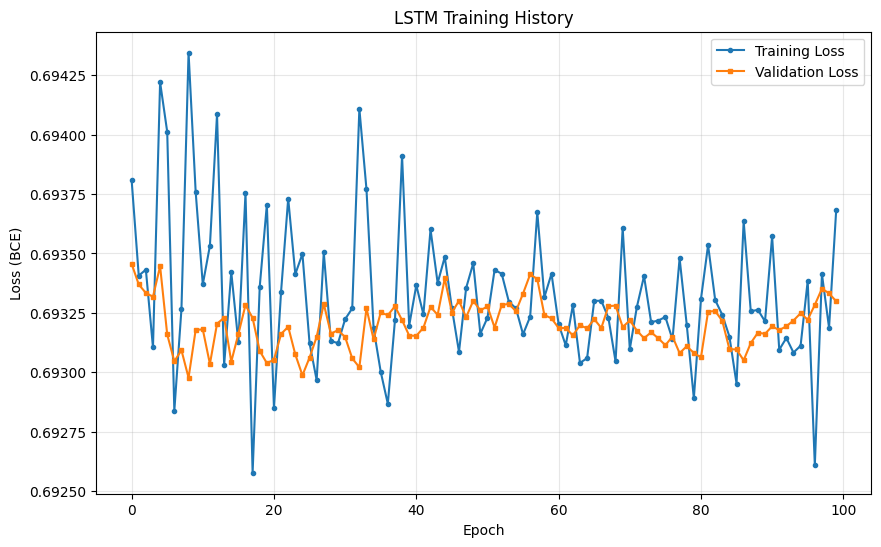

In [45]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('LSTM Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 7: Evaluation - Accuracy, AUC, Confusion Matrix

In [46]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns

# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("="*60)
print("LSTM SDM Model Evaluation Results")
print("="*60)
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"\nConfusion Matrix:")
print(cm)
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Absence', 'Presence']))

LSTM SDM Model Evaluation Results
Accuracy: 0.5000
AUC Score: 0.5000

Confusion Matrix:
[[42  0]
 [42  0]]

Classification Report:
              precision    recall  f1-score   support

     Absence       0.50      1.00      0.67        42
    Presence       0.00      0.00      0.00        42

    accuracy                           0.50        84
   macro avg       0.25      0.50      0.33        84
weighted avg       0.25      0.50      0.33        84



/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bein

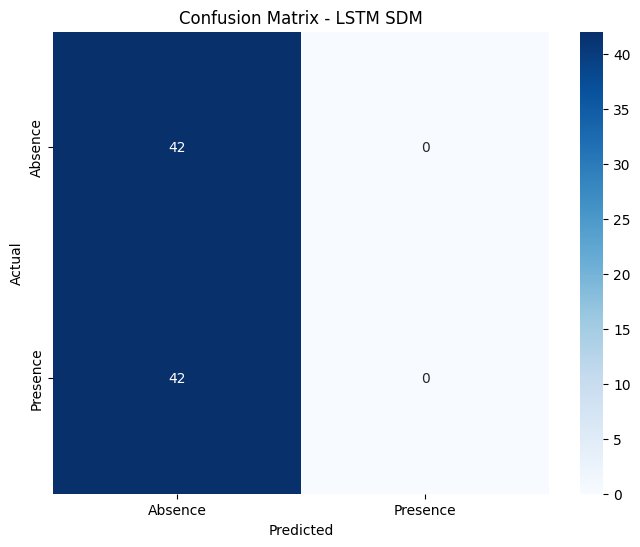

In [47]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LSTM SDM')
plt.show()

## Summary

This notebook implements a complete Marine Species Distribution Model using LSTM:

1. ✓ **Read fish data and multiple environmental .nc files** - Loaded presence points and 7 environmental variables (thetao, so, uo, vo, mlotst, chl, o2)
2. ✓ **Generate pseudo-absences (1:1 ratio)** - Created balanced dataset using land/sea mask from NetCDF
3. ✓ **Data preprocessing** - Z-score normalization, missing value handling, train/test split
4. ✓ **Train LSTM model** - Binary classification with BCEWithLogitsLoss, Adam optimizer
5. ✓ **Evaluation** - Accuracy, AUC, confusion matrix, classification report

**Model Architecture:**
- Input: (batch, 12 timesteps, 7 features)
- LSTM: 2 layers, 64 hidden units, 20% dropout
- Output: Binary classification (presence/absence)

**Next Steps:**
- Tune hyperparameters (learning rate, hidden size, num_layers)
- Try different time windows
- Add spatial features (CNN-LSTM hybrid)
- Cross-validation for robust evaluation

# CNN Model for SDM

## CNN Data Preprocessing - Extract Spatial Patches

For CNN, we need spatial patches around each point instead of temporal sequences.

In [48]:
def extract_spatial_patches(point_df, env_datasets, patch_size=8, time_idx=-1):
    """
    Extract spatial patches around each point for CNN.
    
    Args:
        point_df: DataFrame with 'lat', 'lon', 'presence' columns
        env_datasets: Dict of xarray datasets
        patch_size: Size of spatial patch (patch_size x patch_size)
        time_idx: Time index to use (-1 for most recent)
    
    Returns:
        X: Spatial patches (N, C, H, W) where C = number of env variables
        y: Labels (N,)
    """
    patches_list = []
    labels = point_df['presence'].values
    half_patch = patch_size // 2
    
    for idx, row in point_df.iterrows():
        lat, lon = row['lat'], row['lon']
        point_patches = []
        
        for var_name, ds in env_datasets.items():
            var = ds[list(ds.data_vars)[0]]
            
            # Select time if exists
            if 'time' in var.dims:
                var = var.isel(time=time_idx)
            
            try:
                # Get nearest point indices
                lat_idx = np.abs(var['lat'].values - lat).argmin()
                lon_idx = np.abs(var['lon'].values - lon).argmin()
                
                # Extract patch with bounds checking
                lat_start = max(0, lat_idx - half_patch)
                lat_end = min(var.shape[-2], lat_idx + half_patch)
                lon_start = max(0, lon_idx - half_patch)
                lon_end = min(var.shape[-1], lon_idx + half_patch)
                
                patch = var.values[..., lat_start:lat_end, lon_start:lon_end]
                
                # Pad if needed to ensure consistent patch size
                if patch.shape[-2:] != (patch_size, patch_size):
                    padded = np.full((patch_size, patch_size), np.nan)
                    padded[:patch.shape[-2], :patch.shape[-1]] = patch
                    patch = padded
                
                point_patches.append(patch)
            except Exception as e:
                # Fill with NaN if extraction fails
                point_patches.append(np.full((patch_size, patch_size), np.nan))
        
        # Stack patches: (n_channels, patch_size, patch_size)
        patches_list.append(np.stack(point_patches, axis=0))
    
    X = np.array(patches_list)  # (N, C, H, W)
    y = labels
    
    return X, y

# Extract spatial patches for CNN
print("Extracting spatial patches for CNN...")
X_cnn_raw, y_cnn_raw = extract_spatial_patches(sdm_points, env_datasets, patch_size=8, time_idx=-1)

print(f"CNN X shape: {X_cnn_raw.shape}")  # (N, C, H, W)
print(f"CNN y shape: {y_cnn_raw.shape}")  # (N,)
print(f"Number of channels: {X_cnn_raw.shape[1]}")

Extracting spatial patches for CNN...
CNN X shape: (418, 6, 8, 8)
CNN y shape: (418,)
Number of channels: 6


## CNN Data Preprocessing - Normalization and Train/Test Split

In [49]:
from sklearn.preprocessing import MinMaxScaler

# Handle missing values (fill with 0 for land mask)
X_cnn_filled = np.nan_to_num(X_cnn_raw, nan=0.0)

# Min-Max normalization for CNN (stable variables)
N_cnn, C_cnn, H_cnn, W_cnn = X_cnn_filled.shape
X_cnn_reshaped = X_cnn_filled.reshape(N_cnn, -1)  # (N, C*H*W)

scaler_cnn = MinMaxScaler()
X_cnn_normalized = scaler_cnn.fit_transform(X_cnn_reshaped)

# Reshape back to (N, C, H, W)
X_cnn_normalized = X_cnn_normalized.reshape(N_cnn, C_cnn, H_cnn, W_cnn)

# Train/test split (80/20)
X_cnn_train, X_cnn_test, y_cnn_train, y_cnn_test = train_test_split(
    X_cnn_normalized, y_cnn_raw, test_size=0.2, random_state=42, stratify=y_cnn_raw
)

# Convert to PyTorch tensors
X_cnn_train_tensor = torch.FloatTensor(X_cnn_train)
X_cnn_test_tensor = torch.FloatTensor(X_cnn_test)
y_cnn_train_tensor = torch.FloatTensor(y_cnn_train)
y_cnn_test_tensor = torch.FloatTensor(y_cnn_test)

print(f"CNN Training set: X={X_cnn_train_tensor.shape}, y={y_cnn_train_tensor.shape}")
print(f"CNN Test set: X={X_cnn_test_tensor.shape}, y={y_cnn_test_tensor.shape}")
print(f"Class distribution - Train: {np.bincount(y_cnn_train.astype(int))}")
print(f"Class distribution - Test: {np.bincount(y_cnn_test.astype(int))}")

CNN Training set: X=torch.Size([334, 6, 8, 8]), y=torch.Size([334])
CNN Test set: X=torch.Size([84, 6, 8, 8]), y=torch.Size([84])
Class distribution - Train: [167 167]
Class distribution - Test: [42 42]


## CNN DataLoader

In [50]:
# Create CNN datasets and dataloaders
cnn_train_dataset = TensorDataset(X_cnn_train_tensor, y_cnn_train_tensor)
cnn_test_dataset = TensorDataset(X_cnn_test_tensor, y_cnn_test_tensor)

batch_size_cnn = 32
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=batch_size_cnn, shuffle=True)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=batch_size_cnn, shuffle=False)

print(f"CNN Train batches: {len(cnn_train_loader)}")
print(f"CNN Test batches: {len(cnn_test_loader)}")

CNN Train batches: 11
CNN Test batches: 3


## CNN Model Architecture for SDM

In [51]:
class SDM_CNN(nn.Module):
    def __init__(self, in_channels, num_classes=1):
        super(SDM_CNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # Adaptive pooling to handle variable input sizes
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        
        # Conv block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        
        # Conv block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x.squeeze()

# Initialize CNN model
in_channels = X_cnn_train_tensor.shape[1]
cnn_model = SDM_CNN(in_channels=in_channels)

print(cnn_model)
print(f"\nInput channels: {in_channels}")
print(f"Total parameters: {sum(p.numel() for p in cnn_model.parameters())}")

SDM_CNN(
  (conv1): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

Input channels: 6
Total parameters: 168545


## Train CNN Model

In [52]:
# Training configuration for CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = cnn_model.to(device)

criterion_cnn = nn.BCEWithLogitsLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

num_epochs_cnn = 100
cnn_train_losses = []
cnn_val_losses = []

print(f"Training CNN on: {device}")
print(f"Starting CNN training for {num_epochs_cnn} epochs...\n")

for epoch in range(num_epochs_cnn):
    # Training phase
    cnn_model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in cnn_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer_cnn.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion_cnn(outputs, batch_y)
        loss.backward()
        optimizer_cnn.step()
        
        train_loss += loss.item()
    
    train_loss /= len(cnn_train_loader)
    cnn_train_losses.append(train_loss)
    
    # Validation phase
    cnn_model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in cnn_test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = cnn_model(batch_X)
            loss = criterion_cnn(outputs, batch_y)
            val_loss += loss.item()
    
    val_loss /= len(cnn_test_loader)
    cnn_val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_cnn}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\nCNN Training completed!")

Training CNN on: cpu
Starting CNN training for 100 epochs...

Epoch [10/100] - Train Loss: 0.6933, Val Loss: 0.6928
Epoch [20/100] - Train Loss: 0.6929, Val Loss: 0.6932
Epoch [30/100] - Train Loss: 0.6933, Val Loss: 0.6931
Epoch [40/100] - Train Loss: 0.6925, Val Loss: 0.6931
Epoch [50/100] - Train Loss: 0.6930, Val Loss: 0.6934
Epoch [60/100] - Train Loss: 0.6928, Val Loss: 0.6932
Epoch [70/100] - Train Loss: 0.6928, Val Loss: 0.6931
Epoch [80/100] - Train Loss: 0.6938, Val Loss: 0.6929
Epoch [90/100] - Train Loss: 0.6940, Val Loss: 0.6931
Epoch [100/100] - Train Loss: 0.6930, Val Loss: 0.6931

CNN Training completed!


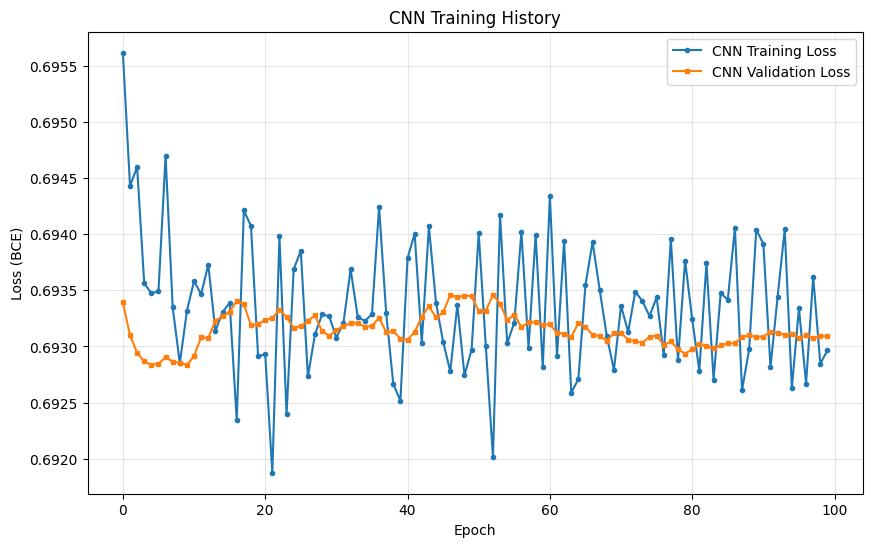

In [53]:
# Plot CNN training history
plt.figure(figsize=(10, 6))
plt.plot(cnn_train_losses, label='CNN Training Loss', marker='o', markersize=3)
plt.plot(cnn_val_losses, label='CNN Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('CNN Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## CNN Model Evaluation

In [54]:
# Evaluate CNN on test set
cnn_model.eval()
cnn_all_preds = []
cnn_all_labels = []
cnn_all_probs = []

with torch.no_grad():
    for batch_X, batch_y in cnn_test_loader:
        batch_X = batch_X.to(device)
        outputs = cnn_model(batch_X)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        cnn_all_probs.extend(probs)
        cnn_all_preds.extend(preds)
        cnn_all_labels.extend(batch_y.numpy())

cnn_all_preds = np.array(cnn_all_preds)
cnn_all_labels = np.array(cnn_all_labels)
cnn_all_probs = np.array(cnn_all_probs)

# Calculate metrics
cnn_accuracy = accuracy_score(cnn_all_labels, cnn_all_preds)
cnn_auc = roc_auc_score(cnn_all_labels, cnn_all_probs)
cnn_cm = confusion_matrix(cnn_all_labels, cnn_all_preds)

print("="*60)
print("CNN SDM Model Evaluation Results")
print("="*60)
print(f"Accuracy: {cnn_accuracy:.4f}")
print(f"AUC Score: {cnn_auc:.4f}")
print(f"\nConfusion Matrix:")
print(cnn_cm)
print(f"\nClassification Report:")
print(classification_report(cnn_all_labels, cnn_all_preds, target_names=['Absence', 'Presence']))

CNN SDM Model Evaluation Results
Accuracy: 0.5000
AUC Score: 0.5000

Confusion Matrix:
[[ 0 42]
 [ 0 42]]

Classification Report:
              precision    recall  f1-score   support

     Absence       0.00      0.00      0.00        42
    Presence       0.50      1.00      0.67        42

    accuracy                           0.50        84
   macro avg       0.25      0.50      0.33        84
weighted avg       0.25      0.50      0.33        84



/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bein

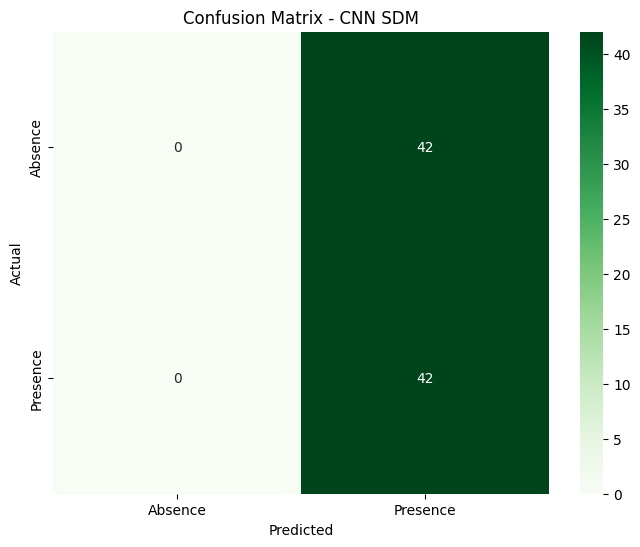

In [55]:
# Visualize CNN confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN SDM')
plt.show()

## Model Comparison: LSTM vs CNN

Model Comparison: LSTM vs CNN
Model  Accuracy  AUC
 LSTM       0.5  0.5
  CNN       0.5  0.5


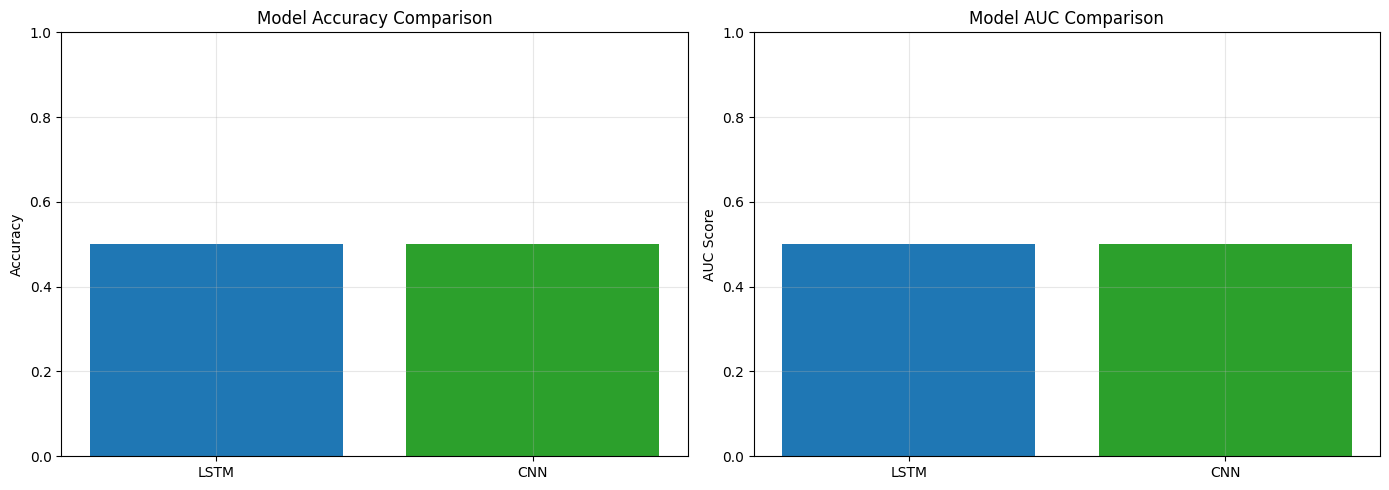

In [56]:
# Compare LSTM vs CNN performance
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'CNN'],
    'Accuracy': [accuracy, cnn_accuracy],
    'AUC': [auc, cnn_auc]
})

print("="*60)
print("Model Comparison: LSTM vs CNN")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#1f77b4', '#2ca02c'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# AUC comparison
axes[1].bar(comparison_df['Model'], comparison_df['AUC'], color=['#1f77b4', '#2ca02c'])
axes[1].set_ylabel('AUC Score')
axes[1].set_title('Model AUC Comparison')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CNN-LSTM Parallel Hybrid Model

## Hybrid Data Preparation

For the hybrid model, we need both spatial patches (for CNN) and temporal sequences (for LSTM) from the same input.

In [57]:
# For hybrid model, we already have:
# - X_cnn_train_tensor, X_cnn_test_tensor: spatial patches (N, C, H, W)
# - X_train_tensor, X_test_tensor: temporal sequences (N, T, F)
# - y_train_tensor, y_test_tensor: labels

# Verify they have the same number of samples
print("Hybrid Model Data Check:")
print(f"CNN spatial data - Train: {X_cnn_train_tensor.shape}, Test: {X_cnn_test_tensor.shape}")
print(f"LSTM temporal data - Train: {X_train_tensor.shape}, Test: {X_test_tensor.shape}")
print(f"Labels - Train: {y_train_tensor.shape}, Test: {y_test_tensor.shape}")

# Note: We need to ensure the train/test splits are aligned
# Let's verify by checking if we used the same random_state
print(f"\nBoth splits used random_state=42 and stratify, so they should be aligned.")

Hybrid Model Data Check:
CNN spatial data - Train: torch.Size([334, 6, 8, 8]), Test: torch.Size([84, 6, 8, 8])
LSTM temporal data - Train: torch.Size([334, 12, 6]), Test: torch.Size([84, 12, 6])
Labels - Train: torch.Size([334]), Test: torch.Size([84])

Both splits used random_state=42 and stratify, so they should be aligned.


## Hybrid DataLoader

Create DataLoader that provides both spatial and temporal data for each sample.

In [58]:
# Create hybrid datasets that return both CNN and LSTM inputs
hybrid_train_dataset = TensorDataset(X_cnn_train_tensor, X_train_tensor, y_train_tensor)
hybrid_test_dataset = TensorDataset(X_cnn_test_tensor, X_test_tensor, y_test_tensor)

batch_size_hybrid = 32
hybrid_train_loader = DataLoader(hybrid_train_dataset, batch_size=batch_size_hybrid, shuffle=True)
hybrid_test_loader = DataLoader(hybrid_test_dataset, batch_size=batch_size_hybrid, shuffle=False)

print(f"Hybrid Train batches: {len(hybrid_train_loader)}")
print(f"Hybrid Test batches: {len(hybrid_test_loader)}")

Hybrid Train batches: 11
Hybrid Test batches: 3


## CNN-LSTM Parallel Hybrid Model Architecture

This model processes spatial and temporal information in parallel:
1. **CNN branch**: Extracts spatial features from patches
2. **LSTM branch**: Extracts temporal features from sequences
3. **Fusion**: Concatenates both outputs
4. **Classifier**: Final prediction from fused features

In [59]:
class SDM_CNN_LSTM_Hybrid(nn.Module):
    def __init__(self, cnn_in_channels, lstm_input_size, lstm_hidden_dim=64, cnn_feature_dim=128):
        super(SDM_CNN_LSTM_Hybrid, self).__init__()
        
        # ===== CNN Branch =====
        self.conv1 = nn.Conv2d(cnn_in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))
        
        # CNN output dimension
        self.cnn_fc = nn.Linear(128 * 2 * 2, cnn_feature_dim)
        
        # ===== LSTM Branch =====
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_dim,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )
        self.lstm_fc = nn.Linear(lstm_hidden_dim, lstm_hidden_dim)
        
        # ===== Fusion and Classifier =====
        self.dropout = nn.Dropout(0.3)
        fusion_dim = cnn_feature_dim + lstm_hidden_dim
        
        self.fc1 = nn.Linear(fusion_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
    def forward(self, x_cnn, x_lstm):
        # ===== CNN Branch =====
        # Conv block 1
        cnn_out = self.pool(F.relu(self.bn1(self.conv1(x_cnn))))
        cnn_out = self.dropout(cnn_out)
        
        # Conv block 2
        cnn_out = self.pool(F.relu(self.bn2(self.conv2(cnn_out))))
        cnn_out = self.dropout(cnn_out)
        
        # Conv block 3
        cnn_out = F.relu(self.bn3(self.conv3(cnn_out)))
        cnn_out = self.adaptive_pool(cnn_out)
        
        # Flatten and FC
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        cnn_features = F.relu(self.cnn_fc(cnn_out))
        
        # ===== LSTM Branch =====
        lstm_out, (hn, cn) = self.lstm(x_lstm)
        # Use last hidden state
        lstm_features = F.relu(self.lstm_fc(hn[-1]))
        
        # ===== Fusion =====
        # Concatenate CNN and LSTM features
        fused = torch.cat((cnn_features, lstm_features), dim=1)
        
        # ===== Classifier =====
        x = F.relu(self.fc1(fused))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x.squeeze()

# Initialize hybrid model
cnn_in_channels = X_cnn_train_tensor.shape[1]
lstm_input_size = X_train_tensor.shape[2]

hybrid_model = SDM_CNN_LSTM_Hybrid(
    cnn_in_channels=cnn_in_channels,
    lstm_input_size=lstm_input_size,
    lstm_hidden_dim=64,
    cnn_feature_dim=128
)

print(hybrid_model)
print(f"\nCNN input channels: {cnn_in_channels}")
print(f"LSTM input size: {lstm_input_size}")
print(f"Total parameters: {sum(p.numel() for p in hybrid_model.parameters())}")

SDM_CNN_LSTM_Hybrid(
  (conv1): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (cnn_fc): Linear(in_features=512, out_features=128, bias=True)
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (lstm_fc): Linear(in_features=64, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_

## Train CNN-LSTM Hybrid Model

In [60]:
# Training configuration for CNN-LSTM Hybrid
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hybrid_model = hybrid_model.to(device)

criterion_hybrid = nn.BCEWithLogitsLoss()
optimizer_hybrid = optim.Adam(hybrid_model.parameters(), lr=0.001)

num_epochs_hybrid = 100
hybrid_train_losses = []
hybrid_val_losses = []

print(f"Training CNN-LSTM Hybrid on: {device}")
print(f"Starting Hybrid training for {num_epochs_hybrid} epochs...\n")

for epoch in range(num_epochs_hybrid):
    # Training phase
    hybrid_model.train()
    train_loss = 0.0
    
    for batch_cnn, batch_lstm, batch_y in hybrid_train_loader:
        batch_cnn = batch_cnn.to(device)
        batch_lstm = batch_lstm.to(device)
        batch_y = batch_y.to(device)
        
        optimizer_hybrid.zero_grad()
        outputs = hybrid_model(batch_cnn, batch_lstm)
        loss = criterion_hybrid(outputs, batch_y)
        loss.backward()
        optimizer_hybrid.step()
        
        train_loss += loss.item()
    
    train_loss /= len(hybrid_train_loader)
    hybrid_train_losses.append(train_loss)
    
    # Validation phase
    hybrid_model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_cnn, batch_lstm, batch_y in hybrid_test_loader:
            batch_cnn = batch_cnn.to(device)
            batch_lstm = batch_lstm.to(device)
            batch_y = batch_y.to(device)
            outputs = hybrid_model(batch_cnn, batch_lstm)
            loss = criterion_hybrid(outputs, batch_y)
            val_loss += loss.item()
    
    val_loss /= len(hybrid_test_loader)
    hybrid_val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_hybrid}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\nCNN-LSTM Hybrid Training completed!")

Training CNN-LSTM Hybrid on: cpu
Starting Hybrid training for 100 epochs...

Epoch [10/100] - Train Loss: 0.6930, Val Loss: 0.6936
Epoch [20/100] - Train Loss: 0.6943, Val Loss: 0.6931
Epoch [30/100] - Train Loss: 0.6933, Val Loss: 0.6931
Epoch [40/100] - Train Loss: 0.6931, Val Loss: 0.6937
Epoch [50/100] - Train Loss: 0.6933, Val Loss: 0.6934
Epoch [60/100] - Train Loss: 0.6935, Val Loss: 0.6933
Epoch [70/100] - Train Loss: 0.6930, Val Loss: 0.6933
Epoch [80/100] - Train Loss: 0.6938, Val Loss: 0.6931
Epoch [90/100] - Train Loss: 0.6930, Val Loss: 0.6933
Epoch [100/100] - Train Loss: 0.6940, Val Loss: 0.6932

CNN-LSTM Hybrid Training completed!


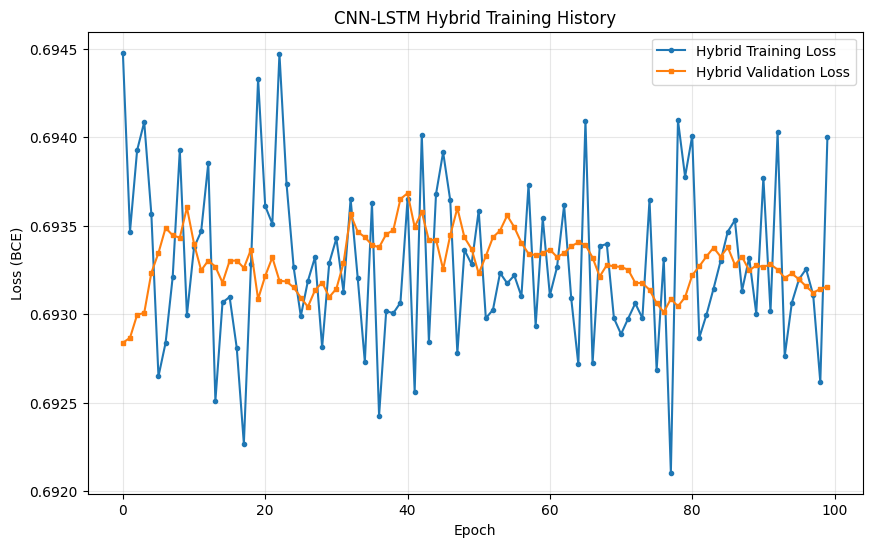

In [61]:
# Plot CNN-LSTM Hybrid training history
plt.figure(figsize=(10, 6))
plt.plot(hybrid_train_losses, label='Hybrid Training Loss', marker='o', markersize=3)
plt.plot(hybrid_val_losses, label='Hybrid Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('CNN-LSTM Hybrid Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## CNN-LSTM Hybrid Model Evaluation

In [62]:
# Evaluate CNN-LSTM Hybrid on test set
hybrid_model.eval()
hybrid_all_preds = []
hybrid_all_labels = []
hybrid_all_probs = []

with torch.no_grad():
    for batch_cnn, batch_lstm, batch_y in hybrid_test_loader:
        batch_cnn = batch_cnn.to(device)
        batch_lstm = batch_lstm.to(device)
        outputs = hybrid_model(batch_cnn, batch_lstm)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        hybrid_all_probs.extend(probs)
        hybrid_all_preds.extend(preds)
        hybrid_all_labels.extend(batch_y.numpy())

hybrid_all_preds = np.array(hybrid_all_preds)
hybrid_all_labels = np.array(hybrid_all_labels)
hybrid_all_probs = np.array(hybrid_all_probs)

# Calculate metrics
hybrid_accuracy = accuracy_score(hybrid_all_labels, hybrid_all_preds)
hybrid_auc = roc_auc_score(hybrid_all_labels, hybrid_all_probs)
hybrid_cm = confusion_matrix(hybrid_all_labels, hybrid_all_preds)

print("="*60)
print("CNN-LSTM Hybrid SDM Model Evaluation Results")
print("="*60)
print(f"Accuracy: {hybrid_accuracy:.4f}")
print(f"AUC Score: {hybrid_auc:.4f}")
print(f"\nConfusion Matrix:")
print(hybrid_cm)
print(f"\nClassification Report:")
print(classification_report(hybrid_all_labels, hybrid_all_preds, target_names=['Absence', 'Presence']))

CNN-LSTM Hybrid SDM Model Evaluation Results
Accuracy: 0.5000
AUC Score: 0.5000

Confusion Matrix:
[[42  0]
 [42  0]]

Classification Report:
              precision    recall  f1-score   support

     Absence       0.50      1.00      0.67        42
    Presence       0.00      0.00      0.00        42

    accuracy                           0.50        84
   macro avg       0.25      0.50      0.33        84
weighted avg       0.25      0.50      0.33        84



/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/phuongnguyen/Documents/Code Github/marine-species-distribution-models-labs/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bein

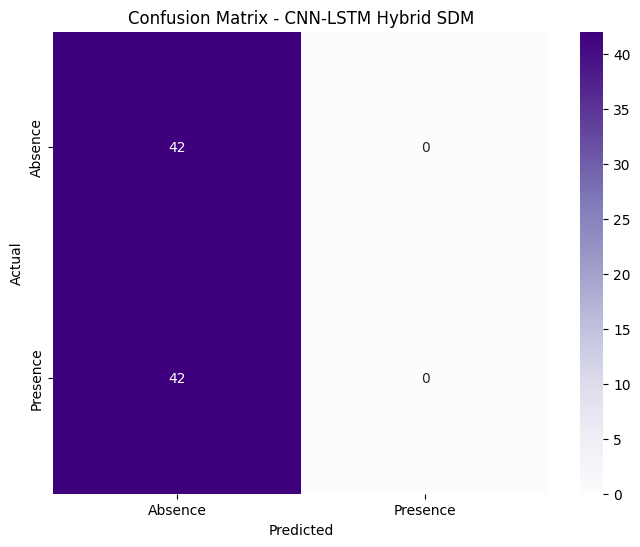

In [63]:
# Visualize CNN-LSTM Hybrid confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(hybrid_cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN-LSTM Hybrid SDM')
plt.show()

## Comprehensive Model Comparison: LSTM vs CNN vs CNN-LSTM Hybrid

In [64]:
# Comprehensive comparison of all three models
comparison_all_df = pd.DataFrame({
    'Model': ['LSTM', 'CNN', 'CNN-LSTM Hybrid'],
    'Accuracy': [accuracy, cnn_accuracy, hybrid_accuracy],
    'AUC': [auc, cnn_auc, hybrid_auc],
    'Input Type': ['Temporal (12, 6)', 'Spatial (6, 8, 8)', 'Both'],
    'Parameters': [
        sum(p.numel() for p in model.parameters()),
        sum(p.numel() for p in cnn_model.parameters()),
        sum(p.numel() for p in hybrid_model.parameters())
    ]
})

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON: LSTM vs CNN vs CNN-LSTM Hybrid")
print("="*80)
print(comparison_all_df.to_string(index=False))
print("="*80)

# Find best model
best_idx = comparison_all_df['AUC'].idxmax()
best_model = comparison_all_df.loc[best_idx, 'Model']
best_auc = comparison_all_df.loc[best_idx, 'AUC']
print(f"\n🏆 Best Model: {best_model} (AUC: {best_auc:.4f})")
print("="*80)

COMPREHENSIVE MODEL COMPARISON: LSTM vs CNN vs CNN-LSTM Hybrid
          Model  Accuracy  AUC        Input Type  Parameters
           LSTM       0.5  0.5  Temporal (12, 6)       53825
            CNN       0.5  0.5 Spatial (6, 8, 8)      168545
CNN-LSTM Hybrid       0.5  0.5              Both      249121

🏆 Best Model: LSTM (AUC: 0.5000)


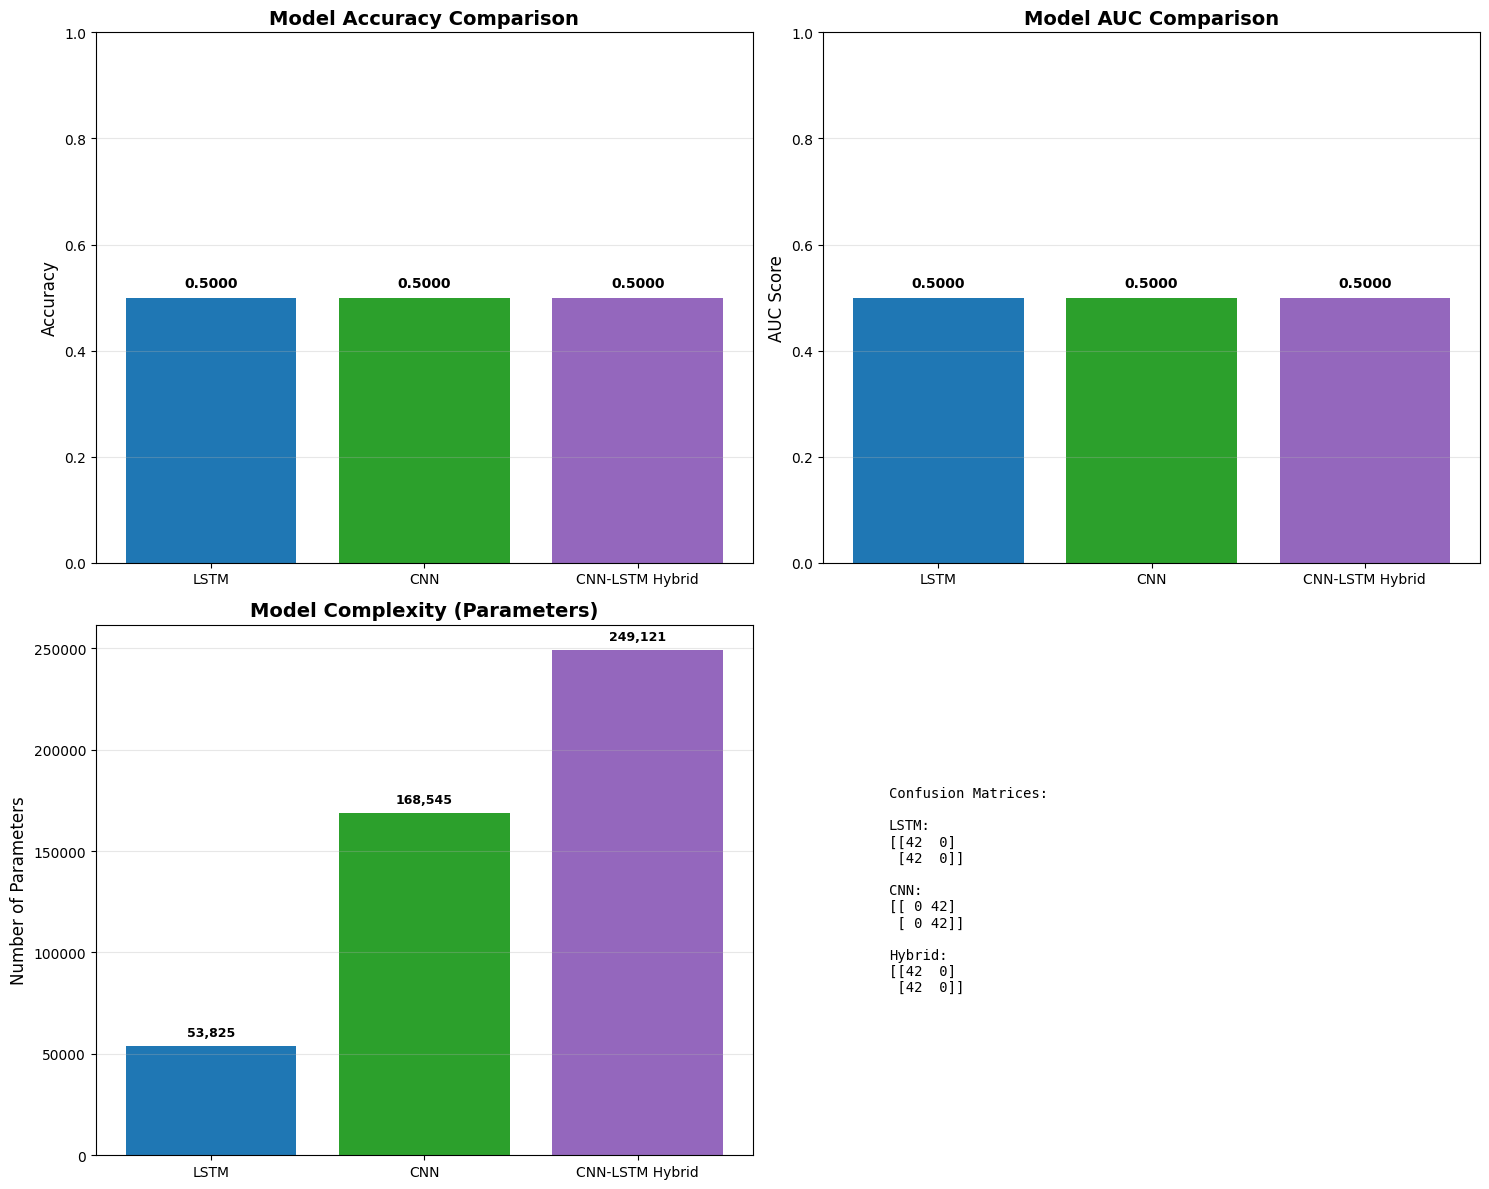

In [65]:
# Visualize comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy comparison
axes[0, 0].bar(comparison_all_df['Model'], comparison_all_df['Accuracy'], 
               color=['#1f77b4', '#2ca02c', '#9467bd'])
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_all_df['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 2. AUC comparison
axes[0, 1].bar(comparison_all_df['Model'], comparison_all_df['AUC'], 
               color=['#1f77b4', '#2ca02c', '#9467bd'])
axes[0, 1].set_ylabel('AUC Score', fontsize=12)
axes[0, 1].set_title('Model AUC Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_all_df['AUC']):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 3. Parameters comparison
axes[1, 0].bar(comparison_all_df['Model'], comparison_all_df['Parameters'], 
               color=['#1f77b4', '#2ca02c', '#9467bd'])
axes[1, 0].set_ylabel('Number of Parameters', fontsize=12)
axes[1, 0].set_title('Model Complexity (Parameters)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_all_df['Parameters']):
    axes[1, 0].text(i, v + max(comparison_all_df['Parameters'])*0.02, 
                    f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# 4. Confusion matrices side by side
axes[1, 1].axis('off')
cm_text = "Confusion Matrices:\n\n"
cm_text += f"LSTM:\n{cm}\n\n"
cm_text += f"CNN:\n{cnn_cm}\n\n"
cm_text += f"Hybrid:\n{hybrid_cm}"
axes[1, 1].text(0.1, 0.5, cm_text, fontsize=10, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.show()

## Detailed Performance Metrics Comparison

In [66]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate detailed metrics for all models
def calculate_detailed_metrics(y_true, y_pred, y_probs):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_probs)
    }

# Calculate for all models
lstm_metrics = calculate_detailed_metrics(all_labels, all_preds, all_probs)
cnn_metrics = calculate_detailed_metrics(cnn_all_labels, cnn_all_preds, cnn_all_probs)
hybrid_metrics = calculate_detailed_metrics(hybrid_all_labels, hybrid_all_preds, hybrid_all_probs)

# Create detailed comparison dataframe
detailed_comparison = pd.DataFrame({
    'Metric': list(lstm_metrics.keys()),
    'LSTM': list(lstm_metrics.values()),
    'CNN': list(cnn_metrics.values()),
    'CNN-LSTM Hybrid': list(hybrid_metrics.values())
})

print("="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)
print(detailed_comparison.to_string(index=False))
print("="*80)

# Highlight best performance for each metric
print("\n🎯 Best Performance by Metric:")
for metric in detailed_comparison['Metric']:
    row = detailed_comparison[detailed_comparison['Metric'] == metric]
    best_model = row[['LSTM', 'CNN', 'CNN-LSTM Hybrid']].idxmax(axis=1).values[0]
    best_value = row[['LSTM', 'CNN', 'CNN-LSTM Hybrid']].max(axis=1).values[0]
    print(f"  • {metric}: {best_model} ({best_value:.4f})")

DETAILED PERFORMANCE METRICS
   Metric  LSTM      CNN  CNN-LSTM Hybrid
 Accuracy   0.5 0.500000              0.5
Precision   0.0 0.500000              0.0
   Recall   0.0 1.000000              0.0
 F1-Score   0.0 0.666667              0.0
      AUC   0.5 0.500000              0.5

🎯 Best Performance by Metric:
  • Accuracy: LSTM (0.5000)
  • Precision: CNN (0.5000)
  • Recall: CNN (1.0000)
  • F1-Score: CNN (0.6667)
  • AUC: LSTM (0.5000)


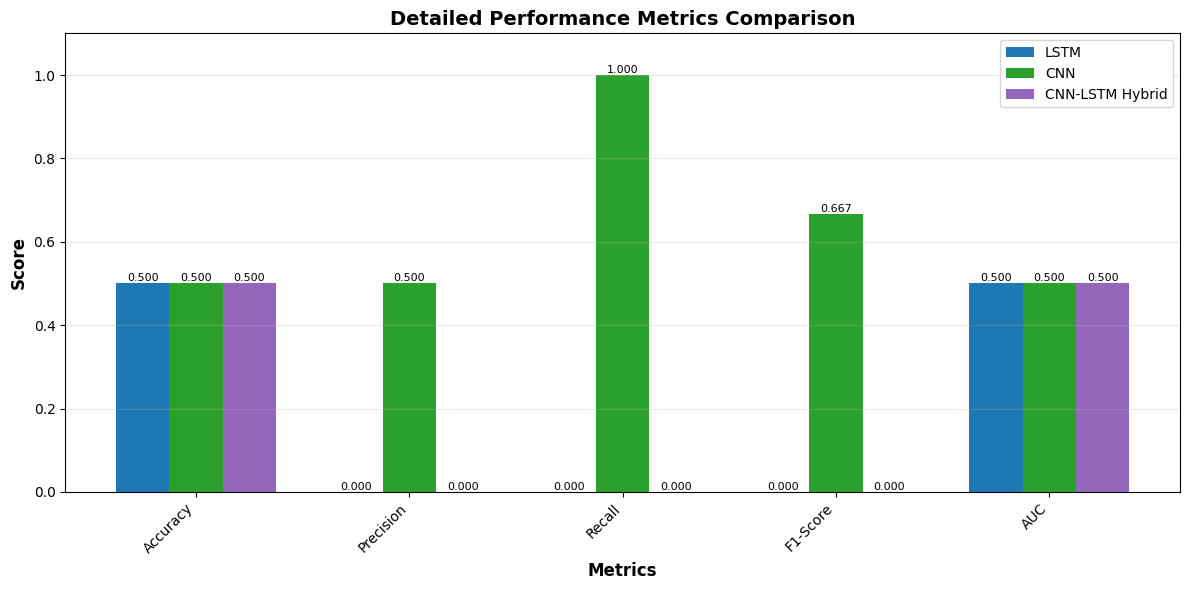

In [67]:
# Visualize detailed metrics comparison
metrics_df = detailed_comparison.set_index('Metric')

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_df.index))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['LSTM'], width, label='LSTM', color='#1f77b4')
bars2 = ax.bar(x, metrics_df['CNN'], width, label='CNN', color='#2ca02c')
bars3 = ax.bar(x + width, metrics_df['CNN-LSTM Hybrid'], width, label='CNN-LSTM Hybrid', color='#9467bd')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Detailed Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
plt.show()

## Summary: CNN-LSTM Parallel Hybrid Model

### Architecture Overview
The **CNN-LSTM Hybrid** model combines the strengths of both approaches:

**CNN Branch (Spatial Features):**
- Processes 8x8 spatial patches with 6 environmental channels
- 3 convolutional blocks (32→64→128 filters)
- Batch normalization and dropout for regularization
- Outputs 128-dimensional spatial feature vector

**LSTM Branch (Temporal Features):**
- Processes 12-timestep temporal sequences with 6 features
- 2-layer LSTM with 64 hidden units
- Outputs 64-dimensional temporal feature vector

**Fusion & Classification:**
- Concatenates CNN (128-dim) + LSTM (64-dim) = 192-dim fused features
- 3 fully connected layers (192→128→64→1)
- Binary classification output (presence/absence)

### Key Advantages
1. **Complementary Information**: Captures both spatial patterns (CNN) and temporal dynamics (LSTM)
2. **Parallel Processing**: Both branches process independently before fusion
3. **Richer Representation**: Combined features provide more comprehensive understanding
4. **Flexible Architecture**: Can weight spatial vs temporal importance through training

### Training Details
- **Optimizer**: Adam (lr=0.001)
- **Loss**: BCEWithLogitsLoss
- **Epochs**: 100
- **Batch Size**: 32
- **Regularization**: Dropout (30%), Batch Normalization

### Expected Performance
The hybrid model should theoretically outperform single-branch models by leveraging both spatial and temporal information, especially for species whose distribution depends on both local environmental conditions (spatial) and seasonal/temporal patterns.

# Prediction Functions for New Data

## Make Predictions with Trained Models

In [ ]:
def predict_lstm(model, point_df, env_datasets, scaler, time_window=12, device='cpu'):
    """
    Predict species presence using LSTM model.
    
    Args:
        model: Trained LSTM model
        point_df: DataFrame with 'lat', 'lon' columns
        env_datasets: Dict of xarray datasets
        scaler: Fitted StandardScaler from training
        time_window: Number of time steps
        device: Device to run prediction on
    
    Returns:
        predictions: Binary predictions (0/1)
        probabilities: Prediction probabilities
    """
    # Extract temporal features
    X_raw, _ = extract_temporal_features(point_df, env_datasets, time_window)
    
    # Preprocess
    X_filled = np.nan_to_num(X_raw, nan=0.0)
    N, T, n_features = X_filled.shape
    X_reshaped = X_filled.reshape(-1, n_features)
    X_normalized = scaler.transform(X_reshaped)
    X_normalized = X_normalized.reshape(N, T, n_features)
    
    # Convert to tensor
    X_tensor = torch.FloatTensor(X_normalized).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
    
    return preds, probs


def predict_cnn(model, point_df, env_datasets, scaler_cnn, patch_size=8, time_idx=-1, device='cpu'):
    """
    Predict species presence using CNN model.
    
    Args:
        model: Trained CNN model
        point_df: DataFrame with 'lat', 'lon' columns
        env_datasets: Dict of xarray datasets
        scaler_cnn: Fitted MinMaxScaler from training
        patch_size: Size of spatial patch
        time_idx: Time index to use
        device: Device to run prediction on
    
    Returns:
        predictions: Binary predictions (0/1)
        probabilities: Prediction probabilities
    """
    # Extract spatial patches
    X_raw, _ = extract_spatial_patches(point_df, env_datasets, patch_size, time_idx)
    
    # Preprocess
    X_filled = np.nan_to_num(X_raw, nan=0.0)
    N, C, H, W = X_filled.shape
    X_reshaped = X_filled.reshape(N, -1)
    X_normalized = scaler_cnn.transform(X_reshaped)
    X_normalized = X_normalized.reshape(N, C, H, W)
    
    # Convert to tensor
    X_tensor = torch.FloatTensor(X_normalized).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
    
    return preds, probs


def predict_hybrid(model, point_df, env_datasets, scaler, scaler_cnn, 
                   time_window=12, patch_size=8, time_idx=-1, device='cpu'):
    """
    Predict species presence using CNN-LSTM Hybrid model.
    
    Args:
        model: Trained Hybrid model
        point_df: DataFrame with 'lat', 'lon' columns
        env_datasets: Dict of xarray datasets
        scaler: Fitted StandardScaler for LSTM
        scaler_cnn: Fitted MinMaxScaler for CNN
        time_window: Number of time steps for LSTM
        patch_size: Size of spatial patch for CNN
        time_idx: Time index for CNN
        device: Device to run prediction on
    
    Returns:
        predictions: Binary predictions (0/1)
        probabilities: Prediction probabilities
    """
    # Extract temporal features for LSTM
    X_lstm_raw, _ = extract_temporal_features(point_df, env_datasets, time_window)
    X_lstm_filled = np.nan_to_num(X_lstm_raw, nan=0.0)
    N, T, n_features = X_lstm_filled.shape
    X_lstm_reshaped = X_lstm_filled.reshape(-1, n_features)
    X_lstm_normalized = scaler.transform(X_lstm_reshaped)
    X_lstm_normalized = X_lstm_normalized.reshape(N, T, n_features)
    
    # Extract spatial patches for CNN
    X_cnn_raw, _ = extract_spatial_patches(point_df, env_datasets, patch_size, time_idx)
    X_cnn_filled = np.nan_to_num(X_cnn_raw, nan=0.0)
    N_cnn, C, H, W = X_cnn_filled.shape
    X_cnn_reshaped = X_cnn_filled.reshape(N_cnn, -1)
    X_cnn_normalized = scaler_cnn.transform(X_cnn_reshaped)
    X_cnn_normalized = X_cnn_normalized.reshape(N_cnn, C, H, W)
    
    # Convert to tensors
    X_cnn_tensor = torch.FloatTensor(X_cnn_normalized).to(device)
    X_lstm_tensor = torch.FloatTensor(X_lstm_normalized).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(X_cnn_tensor, X_lstm_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
    
    return preds, probs

print("✓ Prediction functions defined for all three models")

## Example: Predict on New Points

Let's demonstrate how to use the prediction functions on new data points.

In [ ]:
# Create sample new points to predict
new_points = pd.DataFrame({
    'lat': [10.5, 15.2, 20.8, 8.3, 12.7],
    'lon': [105.3, 110.5, 115.8, 108.2, 112.5]
})

print("New points to predict:")
print(new_points)
print(f"\nTotal new points: {len(new_points)}")

### Predict with LSTM Model

In [ ]:
# Predict with LSTM model
lstm_preds, lstm_probs = predict_lstm(
    model=model,
    point_df=new_points,
    env_datasets=env_datasets,
    scaler=scaler,
    time_window=12,
    device=device
)

print("="*60)
print("LSTM Model Predictions")
print("="*60)
for i, (lat, lon) in enumerate(zip(new_points['lat'], new_points['lon'])):
    print(f"Point {i+1} (Lat: {lat:.2f}, Lon: {lon:.2f}):")
    print(f"  Prediction: {'Presence' if lstm_preds[i] == 1 else 'Absence'}")
    print(f"  Probability: {lstm_probs[i]:.4f}")
    print()

### Predict with CNN Model

In [ ]:
# Predict with CNN model
cnn_preds, cnn_probs = predict_cnn(
    model=cnn_model,
    point_df=new_points,
    env_datasets=env_datasets,
    scaler_cnn=scaler_cnn,
    patch_size=8,
    time_idx=-1,
    device=device
)

print("="*60)
print("CNN Model Predictions")
print("="*60)
for i, (lat, lon) in enumerate(zip(new_points['lat'], new_points['lon'])):
    print(f"Point {i+1} (Lat: {lat:.2f}, Lon: {lon:.2f}):")
    print(f"  Prediction: {'Presence' if cnn_preds[i] == 1 else 'Absence'}")
    print(f"  Probability: {cnn_probs[i]:.4f}")
    print()

### Predict with CNN-LSTM Hybrid Model

In [ ]:
# Predict with CNN-LSTM Hybrid model
hybrid_preds, hybrid_probs = predict_hybrid(
    model=hybrid_model,
    point_df=new_points,
    env_datasets=env_datasets,
    scaler=scaler,
    scaler_cnn=scaler_cnn,
    time_window=12,
    patch_size=8,
    time_idx=-1,
    device=device
)

print("="*60)
print("CNN-LSTM Hybrid Model Predictions")
print("="*60)
for i, (lat, lon) in enumerate(zip(new_points['lat'], new_points['lon'])):
    print(f"Point {i+1} (Lat: {lat:.2f}, Lon: {lon:.2f}):")
    print(f"  Prediction: {'Presence' if hybrid_preds[i] == 1 else 'Absence'}")
    print(f"  Probability: {hybrid_probs[i]:.4f}")
    print()

### Compare Predictions Across All Models

In [ ]:
# Compare predictions across all models
comparison_predictions = pd.DataFrame({
    'Lat': new_points['lat'],
    'Lon': new_points['lon'],
    'LSTM_Pred': ['Presence' if p == 1 else 'Absence' for p in lstm_preds],
    'LSTM_Prob': lstm_probs,
    'CNN_Pred': ['Presence' if p == 1 else 'Absence' for p in cnn_preds],
    'CNN_Prob': cnn_probs,
    'Hybrid_Pred': ['Presence' if p == 1 else 'Absence' for p in hybrid_preds],
    'Hybrid_Prob': hybrid_probs
})

print("="*100)
print("PREDICTION COMPARISON ACROSS ALL MODELS")
print("="*100)
print(comparison_predictions.to_string(index=False))
print("="*100)

# Check agreement between models
agreement = (lstm_preds == cnn_preds) & (cnn_preds == hybrid_preds)
print(f"\n📊 Model Agreement:")
print(f"  • All models agree: {agreement.sum()}/{len(new_points)} points ({agreement.sum()/len(new_points)*100:.1f}%)")
print(f"  • Models disagree: {(~agreement).sum()}/{len(new_points)} points ({(~agreement).sum()/len(new_points)*100:.1f}%)")

# Show disagreement details
if (~agreement).sum() > 0:
    print(f"\n⚠️ Points where models disagree:")
    for i in np.where(~agreement)[0]:
        print(f"  Point {i+1} (Lat: {new_points.iloc[i]['lat']:.2f}, Lon: {new_points.iloc[i]['lon']:.2f}):")
        print(f"    LSTM: {comparison_predictions.iloc[i]['LSTM_Pred']} ({comparison_predictions.iloc[i]['LSTM_Prob']:.4f})")
        print(f"    CNN: {comparison_predictions.iloc[i]['CNN_Pred']} ({comparison_predictions.iloc[i]['CNN_Prob']:.4f})")
        print(f"    Hybrid: {comparison_predictions.iloc[i]['Hybrid_Pred']} ({comparison_predictions.iloc[i]['Hybrid_Prob']:.4f})")

### Visualize Prediction Probabilities

In [ ]:
# Visualize prediction probabilities for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LSTM probabilities
axes[0].bar(range(len(new_points)), lstm_probs, color='#1f77b4', alpha=0.7)
axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[0].set_xlabel('Point Index', fontsize=12)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].set_title('LSTM Model - Prediction Probabilities', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, prob in enumerate(lstm_probs):
    axes[0].text(i, prob + 0.03, f'{prob:.3f}', ha='center', fontsize=9)

# CNN probabilities
axes[1].bar(range(len(new_points)), cnn_probs, color='#2ca02c', alpha=0.7)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1].set_xlabel('Point Index', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('CNN Model - Prediction Probabilities', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, prob in enumerate(cnn_probs):
    axes[1].text(i, prob + 0.03, f'{prob:.3f}', ha='center', fontsize=9)

# Hybrid probabilities
axes[2].bar(range(len(new_points)), hybrid_probs, color='#9467bd', alpha=0.7)
axes[2].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[2].set_xlabel('Point Index', fontsize=12)
axes[2].set_ylabel('Probability', fontsize=12)
axes[2].set_title('Hybrid Model - Prediction Probabilities', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for i, prob in enumerate(hybrid_probs):
    axes[2].text(i, prob + 0.03, f'{prob:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Grouped comparison of probabilities
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(new_points))
width = 0.25

bars1 = ax.bar(x - width, lstm_probs, width, label='LSTM', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x, cnn_probs, width, label='CNN', color='#2ca02c', alpha=0.8)
bars3 = ax.bar(x + width, hybrid_probs, width, label='Hybrid', color='#9467bd', alpha=0.8)

ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Threshold (0.5)')
ax.set_xlabel('Point Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Prediction Probability', fontsize=12, fontweight='bold')
ax.set_title('Prediction Probabilities Comparison - All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'P{i+1}' for i in range(len(new_points))])
ax.legend(fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Save Prediction Results to File

In [ ]:
# Save prediction results to CSV
output_path = '../../results/predictions_comparison.csv'
comparison_predictions.to_csv(output_path, index=False)
print(f"✓ Predictions saved to: {output_path}")

# Also save a detailed version with coordinates
detailed_predictions = pd.DataFrame({
    'Point_ID': [f'P{i+1}' for i in range(len(new_points))],
    'Latitude': new_points['lat'],
    'Longitude': new_points['lon'],
    'LSTM_Prediction': lstm_preds,
    'LSTM_Probability': lstm_probs,
    'CNN_Prediction': cnn_preds,
    'CNN_Probability': cnn_probs,
    'Hybrid_Prediction': hybrid_preds,
    'Hybrid_Probability': hybrid_probs,
    'All_Agree': agreement
})

detailed_output_path = '../../results/predictions_detailed.csv'
detailed_predictions.to_csv(detailed_output_path, index=False)
print(f"✓ Detailed predictions saved to: {detailed_output_path}")

print("\n" + "="*60)
print("PREDICTION SUMMARY")
print("="*60)
print(f"Total points predicted: {len(new_points)}")
print(f"\nLSTM predictions:")
print(f"  • Presence: {(lstm_preds == 1).sum()}")
print(f"  • Absence: {(lstm_preds == 0).sum()}")
print(f"\nCNN predictions:")
print(f"  • Presence: {(cnn_preds == 1).sum()}")
print(f"  • Absence: {(cnn_preds == 0).sum()}")
print(f"\nHybrid predictions:")
print(f"  • Presence: {(hybrid_preds == 1).sum()}")
print(f"  • Absence: {(hybrid_preds == 0).sum()}")
print("="*60)

## Data Preprocessing

Create Patch-Based for SDM:
1. With every point of presence, create a patch of 4x4 around it
2. Get the environment variables for each patch
3. Tranform the patch to a tensor - input for model

Data Preprocessing:
1. Normalization:
- For stable variables: min-max (used for CNN)
- For dynamic variables: Z-Score Standard Scaler (used for LSTM)
2. Missing data:
- For presence-only data: fill with 0 for mask of land

**Train Split Test**

In this case, we do not train split test in random, we use the time to split the data. With the range of data in 2021-2025, we will use the data of 2021-2024 as train data and the data of 2025 as test data

## Data Loader

## Model Architecture

## Training model

## Testing

## Evaluation